In [2]:
!rm -rf /root/.cache/huggingface
!rm -rf /root/.cache/torch

In [3]:
!rm -rf /content/whisper-small-gu-lora-old
!rm -rf /content/whisper-old-checkpoint

In [4]:
!pip install datasets >= 2.6.1
!pip install librosa
!pip install evaluate >=0.30
!pip install jiwer

ERROR: Could not find a version that satisfies the requirement 2.6.1 (from versions: none)
ERROR: No matching distribution found for 2.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 58.5 MB/s eta 0:00:00


In [5]:
from huggingface_hub import notebook_login

notebook_login()

In [6]:
from pathlib import Path
import wandb
from typing import Any, Dict, List, Optional, Union
import gc, json ,os , random

In [7]:
import numpy as np
import torch
import torchaudio
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import soundfile as sf
from collections import Counter

In [8]:
torch.backends.cuda.matmul.allow_tf32 = True

In [9]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [10]:
from dataclasses import dataclass, field

@dataclass
class HParams:

    model_name: str          = "openai/whisper-small"
    language: str            = "Gujarati"
    task: str                = "transcribe"
    target_sr: int           = 16_000
    max_audio_len_sec: float = 30.0
    max_input_length: int    = int(target_sr * max_audio_len_sec)

    # LoRA
    lora_r: int              = 32
    lora_alpha: int          = 64
    lora_dropout: float      = 0.05

    lora_target_modules: List[str] = field(default_factory=lambda: [
        "q_proj", "v_proj",
        "k_proj", "out_proj",
        "fc1", "fc2",
    ])
    bias: str                = "none"

    # Training
    output_dir: str          = "./whisper-small-gu-lora"
    num_train_epochs: int    = 15
    per_device_train_bs: int = 8
    per_device_eval_bs: int  = 8
    gradient_accumulation: int = 2
    learning_rate: float     = 1e-4
    warmup_steps: int        = 300
    weight_decay: float      = 0.01
    max_grad_norm: float      = 1.0
    fp16: bool               = True
    eval_strategy: str       = "epoch"
    save_strategy: str       = "epoch"
    logging_steps: int       = 50
    load_best_model: bool    = True
    metric_for_best: str     = "wer"
    greater_is_better: bool  = False
    generation_max_length: int = 225
    predict_with_generate: bool = True
    early_stopping_patience: int = 4

    # Dataset
    dataset_name: str        = "ai4bharat/kathbath"
    dataset_lang: str        = "gujarati"
    val_frac: float          = 0.1
    test_frac: float         = 0.1

    # W&B
    wandb_project: str       = "whisper-kathbath-gujarati"
    wandb_run_name: str      = "whisper-small-lora-gu"

    # ONNX
    onnx_dir: str            = "./whisper-small-gu-onnx"


hp = HParams()
print(json.dumps(hp.__dict__, indent=2, default=str))

{
  "model_name": "openai/whisper-small",
  "language": "Gujarati",
  "task": "transcribe",
  "target_sr": 16000,
  "max_audio_len_sec": 30.0,
  "max_input_length": 480000,
  "lora_r": 32,
  "lora_alpha": 64,
  "lora_dropout": 0.05,
  "lora_target_modules": [
    "q_proj",
    "v_proj",
    "k_proj",
    "out_proj",
    "fc1",
    "fc2"
  ],
  "bias": "none",
  "output_dir": "./whisper-small-gu-lora",
  "num_train_epochs": 15,
  "per_device_train_bs": 8,
  "per_device_eval_bs": 8,
  "gradient_accumulation": 2,
  "learning_rate": 0.0001,
  "warmup_steps": 300,
  "weight_decay": 0.01,
  "max_grad_norm": 1.0,
  "fp16": true,
  "eval_strategy": "epoch",
  "save_strategy": "epoch",
  "logging_steps": 50,
  "load_best_model": true,
  "metric_for_best": "wer",
  "greater_is_better": false,
  "generation_max_length": 225,
  "predict_with_generate": true,
  "early_stopping_patience": 4,
  "dataset_name": "ai4bharat/kathbath",
  "dataset_lang": "gujarati",
  "val_frac": 0.1,
  "test_frac": 0.1,


In [11]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}  |  GPU: {torch.cuda.get_device_name(0) if DEVICE=='cuda' else 'N/A'}")

Device: cuda  |  GPU: Tesla T4


In [13]:
!pip install wandb

In [14]:
wandb.login()

True

In [17]:
run = wandb.init(
    project=hp.wandb_project,
    name=hp.wandb_run_name,
    config=hp.__dict__,
    resume="allow",
    mode="offline"
)

wandb: WARNING `resume` will be ignored since W&B syncing is set to `offline`. Starting a new run with run id ra6s4num.


In [18]:
from datasets import load_dataset, Audio, DatasetDict
import matplotlib.pyplot as plt
from transformers import WhisperFeatureExtractor, WhisperTokenizer, WhisperProcessor, WhisperForConditionalGeneration, Seq2SeqTrainingArguments, Seq2SeqTrainer, EarlyStoppingCallback


feature_extractor = WhisperFeatureExtractor.from_pretrained(hp.model_name)
tokenizer = WhisperTokenizer.from_pretrained( hp.model_name, language=hp.language, task=hp.task,)
processor = WhisperProcessor.from_pretrained( hp.model_name, language=hp.language, task=hp.task,)



print("Feature extractor sampling rate:", feature_extractor.sampling_rate)
print("Tokenizer vocab size           :", tokenizer.vocab_size)
print("Model max length               :", tokenizer.model_max_length)


preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Feature extractor sampling rate: 16000
Tokenizer vocab size           : 50258
Model max length               : 1024


In [19]:
raw = load_dataset( hp.dataset_name,  hp.dataset_lang,split="train[:27%]", trust_remote_code=True )
print(raw)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ai4bharat/kathbath' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ai4bharat/kathbath' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/22 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

gujarati/valid-00000-of-00002.parquet:   0%|          | 0.00/286M [00:00<?, ?B/s]

...

gujarati/train-00026-of-00028.parquet:   0%|          | 0.00/452M [00:00<?, ?B/s]

gujarati/train-00027-of-00028.parquet:   0%|          | 0.00/445M [00:00<?, ?B/s]

Generating valid split:   0%|          | 0/2905 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/66865 [00:00<?, ? examples/s]

Dataset({
    features: ['fname', 'text', 'audio_filepath', 'lang', 'duration', 'gender', 'speaker_id'],
    num_rows: 18054
})


In [20]:
print(raw['train'][0])

ValueError: Column 'train' doesn't exist.

In [21]:
from sklearn.model_selection import train_test_split
from datasets import DatasetDict

splits = raw.train_test_split(test_size=0.2, seed=SEED)
train_ds = splits["train"]
# train_size = int(0.4 * len(raw["train"]))
# train_ds = raw["train"].select(range(train_size))

In [22]:
# val_ds_full = raw["valid"]
val_test_split = splits["test"].train_test_split(test_size=0.5, seed=SEED)
val_ds  = val_test_split["train"]
test_ds = val_test_split["test"]

In [23]:
raw = DatasetDict({
    "train":      train_ds,
    "validation": val_ds,
    "test":       test_ds,
})

print("\nFinal split sizes:")

for k, v in raw.items():
    print(f"  {k:12s}: {len(v):,} samples")


Final split sizes:
  train       : 14,443 samples
  validation  : 1,805 samples
  test        : 1,806 samples


In [24]:
from datasets import Audio

In [25]:
print(train_ds)
print(val_ds)
print(test_ds)

Dataset({
    features: ['fname', 'text', 'audio_filepath', 'lang', 'duration', 'gender', 'speaker_id'],
    num_rows: 14443
})
Dataset({
    features: ['fname', 'text', 'audio_filepath', 'lang', 'duration', 'gender', 'speaker_id'],
    num_rows: 1805
})
Dataset({
    features: ['fname', 'text', 'audio_filepath', 'lang', 'duration', 'gender', 'speaker_id'],
    num_rows: 1806
})


In [26]:

def check_sample_rates(dataset, n_samples=500):
    rates = Counter()
    # find whichever column holds the audio
    audio_col = next(c for c in dataset.column_names if dataset.features[c].__class__.__name__ == "Audio")
    for ex in dataset.select(range(min(n_samples, len(dataset)))):
        sr = ex[audio_col]["sampling_rate"]
        rates[sr] += 1
    return rates


print("Sample rates in train set:")
sr_counts = check_sample_rates(raw["train"], n_samples=500)

for sr, cnt in sorted(sr_counts.items()):
    print(f"  {sr} Hz  → {cnt} samples")

Sample rates in train set:
  16000 Hz  → 500 samples


In [27]:
def build_vocab(dataset, text_col="sentence", n_samples=None):
    """Build word + character frequency from transcriptions."""
    word_counter = Counter()
    char_counter = Counter()
    subset = dataset if n_samples is None else dataset.select(range(min(n_samples, len(dataset))))
    for ex in subset:
        text = ex.get(text_col, ex.get("text", "")).strip()
        words = text.split()
        word_counter.update(words)
        char_counter.update(list(text.replace(" ", "")))
    return word_counter, char_counter

text_col = "sentence" if "sentence" in raw["train"].column_names else "text"

word_freq, char_freq = build_vocab(raw["train"], text_col=text_col, n_samples=5000)

print(f"Unique words : {len(word_freq):,}")
print(f"Unique chars : {len(char_freq):,}")
print("\nTop-30 words:")
for w, c in word_freq.most_common(30):
    print(f"  {w!r:30s} {c}")
print("\nTop-30 chars:")
for ch, c in char_freq.most_common(30):
    print(f"  {ch!r:10s} {c}")


Unique words : 15,990
Unique chars : 62

Top-30 words:
  'છે'                           2959
  'અને'                          1113
  'આ'                            1066
  'પણ'                           676
  'માટે'                         645
  'પર'                           525
  'કે'                           518
  'એક'                           479
  'કરી'                          427
  'જ'                            425
  'તે'                           384
  'સાથે'                         364
  'હતી'                          364
  'નથી'                          252
  'હતો'                          244
  'હતા'                          242
  'કરવામાં'                      241
  'તો'                           220
  'આવી'                          214
  'હતું'                         188
  'આવે'                          181
  'હોય'                          162
  'દ્વારા'                       157
  'શકે'                          153
  'એ'                            151
  'કરવા'         

In [28]:
vocab_path = Path(hp.output_dir)
vocab_path.mkdir(parents=True, exist_ok=True)
with open(vocab_path / "kathbath_gu_word_vocab.json", "w", encoding="utf-8") as f:
    json.dump(dict(word_freq.most_common()), f, ensure_ascii=False, indent=2)
with open(vocab_path / "kathbath_gu_char_vocab.json", "w", encoding="utf-8") as f:
    json.dump(dict(char_freq.most_common()), f, ensure_ascii=False, indent=2)



In [29]:
def plot_frequency(counter, title, top_n=40, fname=None):
    labels, counts = zip(*counter.most_common(top_n))
    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(range(len(labels)), counts, color=plt.cm.viridis(np.linspace(0.2, 0.9, len(labels))))
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=75, fontsize=8, ha="right")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Frequency")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=150)
        wandb.log({title: wandb.Image(fname)})
    plt.show()

/tmp/ipykernel_5309/1760369023.py:10: UserWarning: Glyph 2750 (\N{GUJARATI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5309/1760369023.py:10: UserWarning: Matplotlib currently does not support Gujarati natively.
  plt.tight_layout()
/tmp/ipykernel_5309/1760369023.py:10: UserWarning: Glyph 2759 (\N{GUJARATI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5309/1760369023.py:10: UserWarning: Glyph 2736 (\N{GUJARATI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5309/1760369023.py:10: UserWarning: Glyph 2728 (\N{GUJARATI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5309/1760369023.py:10: UserWarning: Glyph 2765 (\N{GUJARATI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5309/1760369023.py:10: UserWarning: Glyph 2752 (\N{GUJARATI VOWEL SIGN II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/i

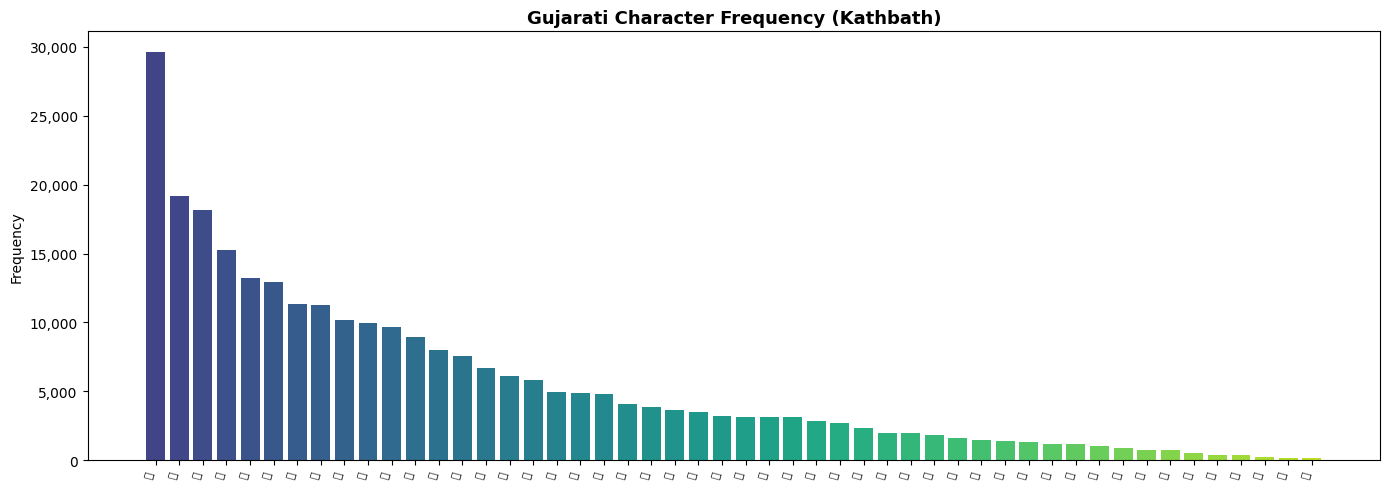

/tmp/ipykernel_5309/1760369023.py:10: UserWarning: Glyph 2715 (\N{GUJARATI LETTER CHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5309/1760369023.py:10: UserWarning: Matplotlib currently does not support Gujarati natively.
  plt.tight_layout()
/tmp/ipykernel_5309/1760369023.py:10: UserWarning: Glyph 2759 (\N{GUJARATI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5309/1760369023.py:10: UserWarning: Glyph 2693 (\N{GUJARATI LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5309/1760369023.py:10: UserWarning: Glyph 2728 (\N{GUJARATI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5309/1760369023.py:10: UserWarning: Glyph 2694 (\N{GUJARATI LETTER AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5309/1760369023.py:10: UserWarning: Glyph 2730 (\N{GUJARATI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5

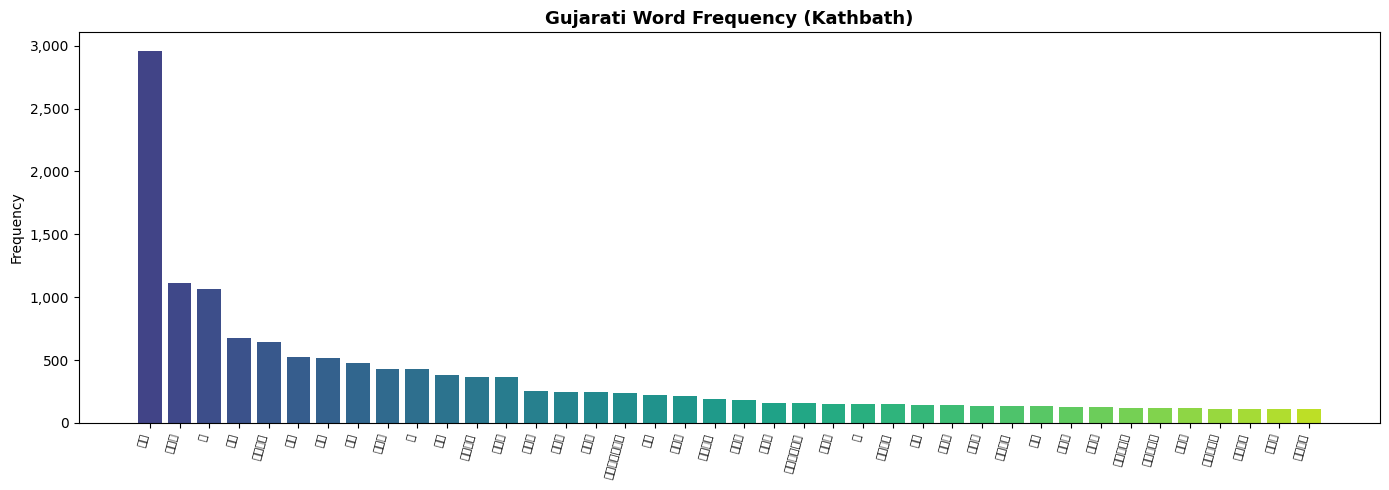

In [30]:
plot_frequency(char_freq, "Gujarati Character Frequency (Kathbath)", top_n=50,
               fname=str(vocab_path / "char_freq.png"))
plot_frequency(word_freq, "Gujarati Word Frequency (Kathbath)", top_n=40,
               fname=str(vocab_path / "word_freq.png"))

In [31]:
raw = raw.cast_column("audio", Audio(sampling_rate=hp.target_sr))

In [32]:
!rm -rf ~/.cache/huggingface/datasets
import gc
gc.collect()
print("✓ Cache cleared, resampled data still in memory")

✓ Cache cleared, resampled data still in memory


In [33]:
def normalize_text(text: str) -> str:
    """Minimal normalization — keep Gujarati Unicode intact."""
    text = text.strip()
    # Remove double spaces
    import re
    text = re.sub(r"\s+", " ", text)
    return text

In [ ]:
from datasets import DatasetDict

AUDIO_COL = "audio_filepath"
TEXT_COL  = "text"

def prepare_dataset(batch):
    audio_data = batch[AUDIO_COL]

    # Make sure audio_data is valid
    if audio_data is None or audio_data["array"] is None:
        return {"input_features": None, "labels": None}

    waveform = np.array(audio_data["array"], dtype=np.float32)
    sr = audio_data["sampling_rate"]

    if len(waveform) == 0:
        return {"input_features": None, "labels": None}

    # truncate or pad
    if len(waveform) > hp.max_input_length:
        waveform = waveform[:hp.max_input_length]

    min_len = int(0.5 * hp.target_sr)
    if len(waveform) < min_len:
        waveform = np.pad(waveform, (0, min_len - len(waveform)))

    # extract features
    input_features = feature_extractor(
        waveform,
        sampling_rate=hp.target_sr,
        return_tensors="np",
        padding="max_length",
        truncation=True,
    ).input_features[0]

    # process text
    text = normalize_text(batch[TEXT_COL])
    labels = tokenizer(text).input_ids
    labels = [t if t != tokenizer.pad_token_id else -100 for t in labels]

    return {"input_features": input_features, "labels": labels}

# Process dataset without batches first
processed = DatasetDict()
for split_name, split_data in raw.items():
    mapped = split_data.map(
        prepare_dataset,
        remove_columns=split_data.column_names,
        num_proc=1,
        batched=False,  # important: each row at a time
        desc=f"Processing {split_name}"
    )
    # filter only valid rows
    mapped = mapped.filter(lambda x: x["input_features"] is not None)
    processed[split_name] = mapped

# Check sizes
for split_name, split_data in processed.items():
    print(f"{split_name} size: {len(split_data)}")

Processing train:   0%|          | 0/14443 [00:00<?, ? examples/s]

Filter:   0%|          | 0/14443 [00:00<?, ? examples/s]

In [ ]:
print(train_ds[5])

In [ ]:
print(processed)
print("input_features shape:", np.array(processed["train"][0]["input_features"]).shape)

In [ ]:
def tokenizer_sanity_check(n=5):
    print("=" * 60)
    print("TOKENIZER SANITY CHECK — Gujarati")
    print("=" * 60)
    indices = random.sample(range(len(raw["train"])), n)
    for i, idx in enumerate(indices):
        orig_text = normalize_text(raw["train"][idx].get(text_col, ""))
        token_ids = tokenizer(orig_text).input_ids
        decoded   = tokenizer.decode(token_ids, skip_special_tokens=True)
        print(f"\n[{i+1}] Original : {orig_text}")
        print(f"     Token IDs: {token_ids[:20]}{'…' if len(token_ids)>20 else ''}")
        print(f"     Decoded  : {decoded}")
        match = " MATCH" if orig_text.strip() == decoded.strip() else "  MISMATCH"
        print(f"     Status   : {match}")


tokenizer_sanity_check(5)

In [ ]:
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any
    decoder_start_token_id: int

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        # Pad input features
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(
            input_features, return_tensors="pt"
        )

        # Pad labels; -100 already embedded for pad positions
        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(
            label_features, return_tensors="pt"
        )
        # Replace pad_token_id with -100
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        # Trim forced decoder start token if prepended
        if (labels[:, 0] == self.decoder_start_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch


In [ ]:
base_model = WhisperForConditionalGeneration.from_pretrained(
    hp.model_name,
    torch_dtype=torch.float16 if hp.fp16 else torch.float32,
)
base_model.config.forced_decoder_ids = None
base_model.config.suppress_tokens    = []
base_model.config.use_cache          = False   # required for gradient checkpointing

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType, PeftModel, prepare_model_for_kbit_training

In [ ]:
lora_config = LoraConfig(
    r=hp.lora_r,
    lora_alpha=hp.lora_alpha,
    target_modules=hp.lora_target_modules,
    lora_dropout=hp.lora_dropout,
    bias=hp.bias,
    task_type=TaskType.SEQ_2_SEQ_LM,
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

# for memory efficiency
model.gradient_checkpointing_enable()

In [ ]:
# encoder  Freeze entirely (optional — saves more VRAM; remove to unfreeze)
for name, param in model.named_parameters():
    if "encoder" in name and "lora" not in name:
        param.requires_grad = False


trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\nTrainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

In [ ]:
!pip install rouge_score

In [ ]:
import evaluate
from rouge_score import rouge_scorer

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")
rouge      = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)


In [ ]:
def compute_metrics(pred):
    pred_ids   = pred.predictions
    label_ids  = pred.label_ids

    # Replace -100 back with pad_token_id for decoding
    label_ids[label_ids == -100] = tokenizer.pad_token_id

    pred_str  = tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    # Normalize decoded text
    pred_str  = [normalize_text(t) for t in pred_str]
    label_str = [normalize_text(t) for t in label_str]

    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    # ROUGE (average over batch)
    r1 = r2 = rl = 0.0
    for pred_t, ref_t in zip(pred_str, label_str):
        scores = rouge.score(ref_t, pred_t)
        r1 += scores["rouge1"].fmeasure
        r2 += scores["rouge2"].fmeasure
        rl += scores["rougeL"].fmeasure
    n = max(len(pred_str), 1)

    return {
        "wer":    round(wer,    4),
        "cer":    round(cer,    4),
        "rouge1": round(r1 / n, 4),
        "rouge2": round(r2 / n, 4),
        "rougeL": round(rl / n, 4),}


In [ ]:
data_collator = DataCollatorSpeechSeq2SeqWithPadding(
    processor=processor,
    decoder_start_token_id=model.config.decoder_start_token_id,
)

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir=hp.output_dir,

    # Batch & gradient
    per_device_train_batch_size=hp.per_device_train_bs,
    per_device_eval_batch_size=hp.per_device_eval_bs,
    gradient_accumulation_steps=hp.gradient_accumulation,
    gradient_checkpointing=True,

    #  Optimiser
    learning_rate=hp.learning_rate,
    warmup_steps=hp.warmup_steps,
    weight_decay=hp.weight_decay,
    max_grad_norm=hp.max_grad_norm,
    num_train_epochs=hp.num_train_epochs,
    lr_scheduler_type="cosine",

    #  Precision
    fp16=hp.fp16,

    #  Eval & saving
    eval_strategy=hp.eval_strategy,
    save_strategy=hp.save_strategy,
    logging_steps=hp.logging_steps,
    load_best_model_at_end=hp.load_best_model,
    metric_for_best_model=hp.metric_for_best,
    greater_is_better=hp.greater_is_better,
    save_total_limit=3,

    # Generation
    predict_with_generate=hp.predict_with_generate,
    generation_max_length=hp.generation_max_length,

    #  W&B
    report_to="wandb",
    run_name=hp.wandb_run_name,

    #  Misc
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    remove_unused_columns=False,
    push_to_hub=False,
    label_names=["labels"],
)


In [ ]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=processed["train"],
    eval_dataset=processed["validation"],
     processing_class=processor.feature_extractor,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=hp.early_stopping_patience)],
)

In [ ]:
processed = processed.filter(
    lambda x: x["input_features"] is not None and x["labels"] is not None
)

In [ ]:
from datasets import DatasetDict

processed = DatasetDict()
for split_name, split_data in raw.items():
    mapped = split_data.map(
        prepare_dataset,
        remove_columns=split_data.column_names,
        num_proc=1,  # start with 1 for debugging
        desc=f"Processing {split_name}"
    )
    # remove samples with None
    mapped = mapped.filter(lambda x: x["input_features"] is not None)
    processed[split_name] = mapped

# check sizes
for split_name, split_data in processed.items():
    print(f"{split_name} size: {len(split_data)}")

In [ ]:
for i in range(5):
    print(processed["train"][i])

In [ ]:
print("Starting training…")
train_result = trainer.train()

# Save LoRA adapters + training state
trainer.save_model(hp.output_dir)
trainer.log_metrics("train", train_result.metrics)
trainer.save_metrics("train", train_result.metrics)
trainer.save_state()
print("Training complete. Adapter saved to:", hp.output_dir)

In [ ]:
def plot_training_curves(log_history: List[Dict], save_dir: str = "."):
    """Parse trainer log_history and plot loss + WER/CER curves."""
    train_steps, train_loss = [], []
    eval_steps, eval_loss   = [], []
    eval_wer, eval_cer      = [], []

    for entry in log_history:
        step = entry.get("step", 0)
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(step)
            train_loss.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(step)
            eval_loss.append(entry["eval_loss"])
        if "eval_wer" in entry:
            eval_wer.append(entry["eval_wer"])
        if "eval_cer" in entry:
            eval_cer.append(entry["eval_cer"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(train_steps, train_loss, label="Train Loss", color="#1f77b4", lw=1.5)
    axes[0].plot(eval_steps,  eval_loss,  label="Val Loss",   color="#ff7f0e", lw=1.5, marker="o", ms=4)
    axes[0].set_title("Loss Curve", fontweight="bold")
    axes[0].set_xlabel("Steps"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # WER
    axes[1].plot(eval_steps[:len(eval_wer)], eval_wer, color="#2ca02c", lw=1.5, marker="s", ms=4)
    axes[1].set_title("Validation WER", fontweight="bold")
    axes[1].set_xlabel("Steps"); axes[1].set_ylabel("WER (lower = better)")
    axes[1].grid(alpha=0.3)

    # CER
    axes[2].plot(eval_steps[:len(eval_cer)], eval_cer, color="#d62728", lw=1.5, marker="^", ms=4)
    axes[2].set_title("Validation CER", fontweight="bold")
    axes[2].set_xlabel("Steps"); axes[2].set_ylabel("CER (lower = better)")
    axes[2].grid(alpha=0.3)

    plt.suptitle("Whisper-Small LoRA | Kathbath Gujarati", fontsize=14, fontweight="bold")
    plt.tight_layout()
    fpath = os.path.join(save_dir, "training_curves.png")
    plt.savefig(fpath, dpi=150)
    wandb.log({"training_curves": wandb.Image(fpath)})
    plt.show()


In [ ]:
plot_training_curves(trainer.state.log_history, save_dir=hp.output_dir)

In [ ]:
def plot_spectrograms(dataset_raw, n=5, text_col="sentence", save_dir="."):
    indices = random.sample(range(len(dataset_raw)), n)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n))
    if n == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        ex = dataset_raw[idx]
        waveform = np.array(ex["audio"]["array"], dtype=np.float32)
        sr = ex["audio"]["sampling_rate"]
        text = ex.get(text_col, ex.get("text", ""))

        S = librosa.feature.melspectrogram(y=waveform, sr=sr, n_mels=80, fmax=8000)
        S_db = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel",
                                        fmax=8000, ax=ax, cmap="magma")
        fig.colorbar(img, ax=ax, format="%+2.0f dB")
        ax.set_title(f"[{idx}] {text[:80]}…" if len(text) > 80 else f"[{idx}] {text}",
                     fontsize=9)
    plt.suptitle("Mel Spectrograms — Kathbath Gujarati", fontsize=12, fontweight="bold")
    plt.tight_layout()
    fpath = os.path.join(save_dir, "spectrograms.png")
    plt.savefig(fpath, dpi=150)
    wandb.log({"spectrograms": wandb.Image(fpath)})
    plt.show()

In [ ]:
plot_spectrograms(raw["train"], n=5, text_col=text_col, save_dir=hp.output_dir)

In [ ]:
print("---------------Test Eval--------------")
test_results = trainer.evaluate(
    eval_dataset=processed["test"],
    metric_key_prefix="test",
)
trainer.log_metrics("test", test_results)
trainer.save_metrics("test", test_results)
print(test_results)
wandb.log(test_results)

In [ ]:
!pip install optimum[onnxruntime]

In [ ]:
def run_full_inference(model, processor, dataset_raw, dataset_proc, n_samples=None, text_col="sentence"):
    """Run inference on test set and compute detailed metrics."""
    model.eval()
    all_preds, all_refs = [], []

    n = n_samples or len(dataset_proc)
    indices = list(range(min(n, len(dataset_proc))))

    print(f"Running inference on {len(indices)} test samples…")
    batch_size = 8
    for start in range(0, len(indices), batch_size):
        batch_idx = indices[start:start + batch_size]
        batch_features = torch.tensor(
            np.stack([dataset_proc[i]["input_features"] for i in batch_idx]),
            dtype=torch.float16 if hp.fp16 else torch.float32,
        ).to(DEVICE)

        with torch.no_grad():
            pred_ids = model.generate(
                batch_features,
                forced_decoder_ids=processor.get_decoder_prompt_ids(
                    language=hp.language, task=hp.task
                ),
                max_new_tokens=hp.generation_max_length,
            )

        preds = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
        refs  = [
            normalize_text(dataset_raw[i].get(text_col, ""))
            for i in batch_idx
        ]
        all_preds.extend([normalize_text(p) for p in preds])
        all_refs.extend(refs)

    wer_score = wer_metric.compute(predictions=all_preds, references=all_refs)
    cer_score = cer_metric.compute(predictions=all_preds, references=all_refs)

    r1 = r2 = rl = 0.0
    for pred_t, ref_t in zip(all_preds, all_refs):
        s = rouge.score(ref_t, pred_t)
        r1 += s["rouge1"].fmeasure
        r2 += s["rouge2"].fmeasure
        rl += s["rougeL"].fmeasure
    n_b = max(len(all_preds), 1)

    results = {
        "test_wer":    round(wer_score, 4),
        "test_cer":    round(cer_score, 4),
        "test_rouge1": round(r1 / n_b, 4),
        "test_rouge2": round(r2 / n_b, 4),
        "test_rougeL": round(rl / n_b, 4),
    }
    print("\n── Final Test Metrics ──────────────────────────────")
    for k, v in results.items():
        print(f"  {k:20s}: {v:.4f}")

    wandb.log(results)

    # Print 10 example pred vs ref
    print("\n── Sample Predictions ──────────────────────────────")
    for i in range(min(10, len(all_preds))):
        print(f"[{i+1}] REF : {all_refs[i]}")
        print(f"     PRED: {all_preds[i]}")
        print()

    return all_preds, all_refs, results

In [ ]:
best_model = WhisperForConditionalGeneration.from_pretrained(hp.model_name)
best_model.config.forced_decoder_ids = None
best_model.config.suppress_tokens    = []
best_model = PeftModel.from_pretrained(best_model, hp.output_dir)
best_model = best_model.merge_and_unload()   # merge LoRA weights for inference speed
best_model = best_model.to(DEVICE)
if hp.fp16:
    best_model = best_model.half()

preds, refs, final_metrics = run_full_inference(
    best_model, processor,
    raw["test"], processed["test"],
    text_col=text_col,
)

In [ ]:
BEST_MODEL_DIR = Path(hp.output_dir) / "best_merged"
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model.save_pretrained(str(BEST_MODEL_DIR))
processor.save_pretrained(str(BEST_MODEL_DIR))
tokenizer.save_pretrained(str(BEST_MODEL_DIR))
print("Merged model saved to:", BEST_MODEL_DIR)

In [ ]:
torch.save(
    {
        "model_state_dict": best_model.state_dict(),
        "hyperparams": hp.__dict__,
        "final_metrics": final_metrics,
    },
    str(BEST_MODEL_DIR / "checkpoint.pt"),
)
print("PyTorch checkpoint saved.")

In [ ]:
from optimum.onnxruntime import ORTModelForSpeechSeq2Seq
from transformers import pipeline as hf_pipeline

print("\nExporting to ONNX (optimum)…")
ONNX_DIR = Path(hp.onnx_dir)
ONNX_DIR.mkdir(parents=True, exist_ok=True)

ort_model = ORTModelForSpeechSeq2Seq.from_pretrained(
    str(BEST_MODEL_DIR),
    export=True,
    provider="CPUExecutionProvider",
)
ort_model.save_pretrained(str(ONNX_DIR))
processor.save_pretrained(str(ONNX_DIR))
print(f"ONNX model saved to: {ONNX_DIR}")

In [ ]:
onnx_pipe = hf_pipeline(
    "automatic-speech-recognition",
    model=ort_model,
    tokenizer=tokenizer,
    feature_extractor=feature_extractor,
)
sample_audio = raw["test"][0]["audio"]
onnx_out = onnx_pipe({"sampling_rate": sample_audio["sampling_rate"],
                        "raw": sample_audio["array"]})
print("ONNX test output:", onnx_out["text"])
print("Reference        :", normalize_text(raw["test"][0].get(text_col, "")))

In [ ]:
import zipfile
import shutil
from google.colab import files as colab_files

In [ ]:
def zip_and_download(source_dir: str, zip_name: str):
    """Zip a directory and trigger a browser download in Colab."""
    zip_path = f"/content/{zip_name}"
    print(f"Zipping {source_dir} → {zip_path} …")
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for fpath in Path(source_dir).rglob("*"):
            if fpath.is_file():
                zf.write(fpath, arcname=fpath.relative_to(source_dir))
    size_mb = os.path.getsize(zip_path) / 1e6
    print(f"Archive size: {size_mb:.1f} MB")
    colab_files.download(zip_path)
    print(f"Download triggered for: {zip_name}")

In [ ]:
print("\n=== Option B: LoRA adapter only ===")
zip_and_download(hp.output_dir, "whisper_small_gu_lora_adapter.zip")

In [ ]:
print("\n=== Option C: ONNX model ===")
zip_and_download(hp.onnx_dir, "whisper_small_gu_onnx.zip")

In [ ]:
print("\n=== Option D: Raw PyTorch checkpoint (.pt) ===")
colab_files.download(str(BEST_MODEL_DIR / "checkpoint.pt"))
print("Download triggered for: checkpoint.pt")

In [ ]:
artifact = wandb.Artifact("whisper-small-gu-lora", type="model")
artifact.add_dir(hp.output_dir)
run.log_artifact(artifact)
wandb.finish()
print("W&B run finished. All artifacts logged.")